In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()

X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset shape: (1797, 64)
Number of classes: 10


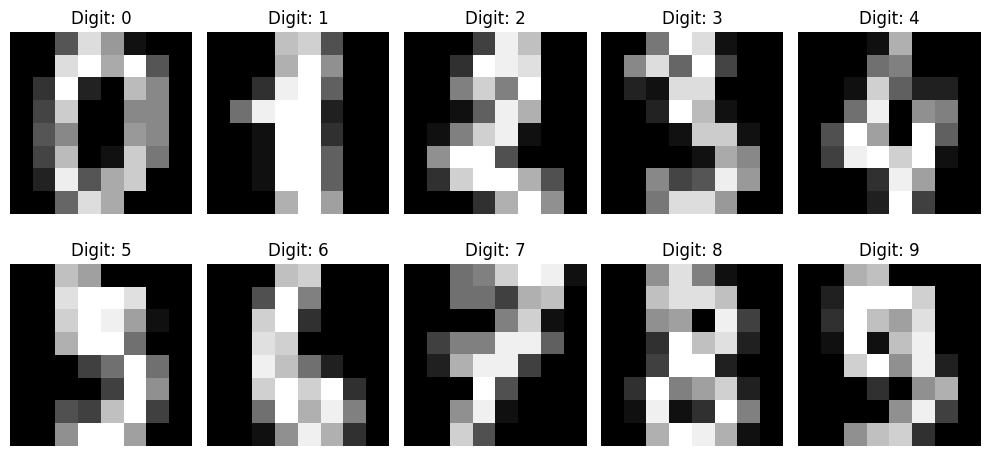

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
k = 20

In [ ]:
start = time.perf_counter()

pca_normal = PCA(
    n_components=k,
    svd_solver="full"
)

X_normal = pca_normal.fit_transform(X)

normal_time = time.perf_counter() - start

print("Normal PCA time:", normal_time, "seconds")
print("Output shape:", X_normal.shape)
print("Explained variance:", pca_normal.explained_variance_ratio_.sum())

Normal PCA time: 0.009738393999896289 seconds
Output shape: (1797, 20)
Explained variance: 0.8943031165985262


In [ ]:
start = time.perf_counter()

pca_random = PCA(
    n_components=k,
    svd_solver="randomized",
    random_state=42
)

X_random = pca_random.fit_transform(X)

random_time = time.perf_counter() - start

print("Randomized PCA time:", random_time, "seconds")
print("Output shape:", X_random.shape)
print("Explained variance:", pca_random.explained_variance_ratio_.sum())

Randomized PCA time: 0.3155357099999492 seconds
Output shape: (1797, 20)
Explained variance: 0.8942973409036886


In [ ]:
print("========== COMPARISON ==========")

print(f"Normal PCA time:     {normal_time:.6f} seconds")
print(f"Randomized PCA time: {random_time:.6f} seconds")

print()

print(f"Normal explained variance:     "
      f"{pca_normal.explained_variance_ratio_.sum():.6f}")

print(f"Randomized explained variance: "
      f"{pca_random.explained_variance_ratio_.sum():.6f}")

========== COMPARISON ==========
Normal PCA time:     0.009738 seconds
Randomized PCA time: 0.315536 seconds

Normal explained variance:     0.894303
Randomized explained variance: 0.894297


In [ ]:
X_normal_reconstructed = pca_normal.inverse_transform(X_normal)
X_random_reconstructed = pca_random.inverse_transform(X_random)

In [ ]:
normal_error = np.mean(
    (X - X_normal_reconstructed) ** 2
)

random_error = np.mean(
    (X - X_random_reconstructed) ** 2
)

print("Normal PCA reconstruction error:", normal_error)
print("Randomized PCA reconstruction error:", random_error)

Normal PCA reconstruction error: 1.9842587189432237
Randomized PCA reconstruction error: 1.9843671466704424


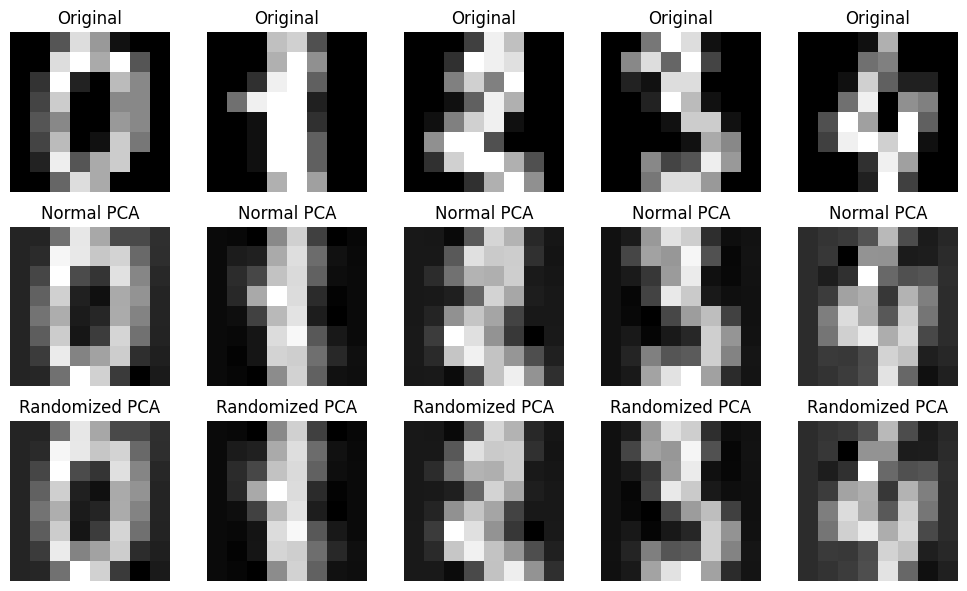

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(5):

    # Original
    axes[0, i].imshow(
        digits.images[i],
        cmap="gray"
    )
    axes[0, i].set_title("Original")

    # Normal PCA
    axes[1, i].imshow(
        X_normal_reconstructed[i].reshape(8, 8),
        cmap="gray"
    )
    axes[1, i].set_title("Normal PCA")

    # Randomized PCA
    axes[2, i].imshow(
        X_random_reconstructed[i].reshape(8, 8),
        cmap="gray"
    )
    axes[2, i].set_title("Randomized PCA")

    for j in range(3):
        axes[j, i].axis("off")

plt.tight_layout()
plt.show()